# 07 — Dual-Stream Conv-LSTM: RGB + Lucas-Kanade (Gabungan)

Menggabungkan stream RGB (baseline) dengan stream Lucas-Kanade optical flow
menggunakan arsitektur dua encoder independen dan attention fusion.

**Dataset:** SIBI Dependent Gabungan — 18 kelas (number + alphabet + word)

| Stream | Input | Shape |
|--------|-------|-------|
| RGB | raw_lips | [B, 3, 30, 96, 96] |
| LK Flow | flows_lucaskanade | [B, 3, 29, 96, 96] |

**Hasil pembanding:**
- Baseline RGB Conv-LSTM: Test Acc **83.06%**
- LK Flow Conv-LSTM: Test Acc **50.83%**

In [1]:
# ── Cell 1: Import ──────────────────────────────────────────────────────────
import json, time, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.notebook import tqdm
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import (
    confusion_matrix, classification_report,
    f1_score, precision_score, recall_score
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch : {torch.__version__}')
print(f'Device  : {device}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB')

PyTorch : 2.11.0+cu128
Device  : cuda
GPU     : NVIDIA GeForce RTX 5050 Laptop GPU
VRAM    : 8.09 GB


In [2]:
# ── Cell 2: Config ──────────────────────────────────────────────────────────
BASE_DIR     = Path('/home/wipra-ranum/Documents/Skripsi/LipReading')
PROJECT_ROOT = BASE_DIR / 'Lip_Reading_Gabungan'
RGB_DIR      = PROJECT_ROOT / 'preprocessed' / 'dependent' / 'raw_lips'
FLOW_DIR     = PROJECT_ROOT / 'preprocessed' / 'dependent' / 'flows_lucaskanade'
MODELS_DIR   = PROJECT_ROOT / 'models'
RESULTS_DIR  = PROJECT_ROOT / 'results' / 'dualstream_lk_training'
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

with open(PROJECT_ROOT / 'config.json') as f:
    cfg = json.load(f)

CLASSES      = cfg['data']['classes']
NUM_CLASSES  = len(CLASSES)
IDX_TO_CLASS = {i: c for i, c in enumerate(CLASSES)}
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}

BATCH_SIZE   = 8
NUM_EPOCHS   = 100
LR           = 0.001
WEIGHT_DECAY = 1e-5
SEED         = 42
RGB_SEQ_LEN  = 30    # frame RGB
FLOW_SEQ_LEN = 29    # frame flow (T-1)

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

print(f'RGB     : {RGB_DIR}')
print(f'Flow    : {FLOW_DIR}')
print(f'Classes : {NUM_CLASSES} kelas — {CLASSES}')
print(f'Epochs  : {NUM_EPOCHS} | Batch: {BATCH_SIZE} | LR: {LR}')
print(f'RGB seq : {RGB_SEQ_LEN} frames | Flow seq: {FLOW_SEQ_LEN} frames')

RGB     : /home/wipra-ranum/Documents/Skripsi/LipReading/Lip_Reading_Gabungan/preprocessed/dependent/raw_lips
Flow    : /home/wipra-ranum/Documents/Skripsi/LipReading/Lip_Reading_Gabungan/preprocessed/dependent/flows_lucaskanade
Classes : 18 kelas — ['1', '2', '3', '8', '9', '10', 'a', 'b', 'c', 'd', 'e', 'f', 'buku', 'dia', 'saya', 'keliling', 'kelompok', 'sekarang']
Epochs  : 100 | Batch: 8 | LR: 0.001
RGB seq : 30 frames | Flow seq: 29 frames


In [3]:
# ── Cell 3: Dataset ─────────────────────────────────────────────────────────
class DualStreamDataset(Dataset):
    """
    Load pasangan (RGB, LK flow) untuk setiap sampel.

    RGB  : raw_lips          → [T, H, W, 3] uint8, dibagi 255 → [0, 1]
    Flow : flows_lucaskanade → [T-1, H, W, 3] float32, sudah z-score

    Augmentasi:
      - Horizontal flip: flip spasial + negate channel u (flow_x).
        Negate u wajib dilakukan karena flip tanpa negate membuat arah
        gerak menjadi kebalikannya tapi bertanda sama → semantik salah.
    """

    def __init__(self, rgb_dir, flow_dir, classes, split,
                 rgb_seq=30, flow_seq=29, augment=False):
        self.rgb_dir   = Path(rgb_dir)
        self.flow_dir  = Path(flow_dir)
        self.rgb_seq   = rgb_seq
        self.flow_seq  = flow_seq
        self.augment   = augment
        cls_map        = {c: i for i, c in enumerate(classes)}

        self.samples = []
        for cls in classes:
            for rf in sorted((self.rgb_dir / split / cls).glob('*.npy')):
                ff = self.flow_dir / split / cls / rf.name
                if ff.exists():
                    self.samples.append((rf, ff, cls_map[cls]))
                    
        missing = 0
        for cls in classes:
            rn = len(list((self.rgb_dir  / split / cls).glob('*.npy')))
            fn = len(list((self.flow_dir / split / cls).glob('*.npy')))
            if rn != fn:
                missing += abs(rn - fn)
        if missing:
            print(f'  Warning: {missing} file tidak berpasangan di split={split}')
        print(f'  {split:5s}: {len(self.samples)} pasangan')

    def _fix_len(self, seq, target):
        T = len(seq)
        if T == target:
            return seq
        if T < target:
            pad = np.zeros((target - T, *seq.shape[1:]), dtype=np.float32)
            return np.concatenate([seq, pad])
        return seq[np.linspace(0, T - 1, target, dtype=int)]

    def _augment(self, rgb, flow):
        # horizontal flip + negate u (wajib!)
        if np.random.random() > 0.5:
            rgb  = rgb[:, :, ::-1, :].copy()
            flow = flow[:, :, ::-1, :].copy()
            flow[..., 0] *= -1
        return rgb, flow

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, i):
        rf, ff, label = self.samples[i]
        rgb  = np.load(rf).astype(np.float32) / 255.0   # [T, H, W, 3]
        flow = np.load(ff).astype(np.float32)            # [T-1, H, W, 3]

        if self.augment:
            rgb, flow = self._augment(rgb, flow)

        rgb  = self._fix_len(rgb,  self.rgb_seq)    # [30, H, W, 3]
        flow = self._fix_len(flow, self.flow_seq)   # [29, H, W, 3]

        # [T, H, W, C] → [C, T, H, W]
        rgb  = torch.from_numpy(rgb.transpose(3, 0, 1, 2))
        flow = torch.from_numpy(flow.transpose(3, 0, 1, 2))
        return rgb, flow, torch.tensor(label, dtype=torch.long)

In [4]:
# ── Cell 4: DataLoader ──────────────────────────────────────────────────────
print('Loading datasets...')
train_ds = DualStreamDataset(RGB_DIR, FLOW_DIR, CLASSES, 'train',
                             RGB_SEQ_LEN, FLOW_SEQ_LEN, augment=True)
val_ds   = DualStreamDataset(RGB_DIR, FLOW_DIR, CLASSES, 'val',
                             RGB_SEQ_LEN, FLOW_SEQ_LEN, augment=False)
test_ds  = DualStreamDataset(RGB_DIR, FLOW_DIR, CLASSES, 'test',
                             RGB_SEQ_LEN, FLOW_SEQ_LEN, augment=False)

kw = dict(batch_size=BATCH_SIZE, num_workers=4, pin_memory=True)
train_loader = DataLoader(train_ds, shuffle=True,  **kw)
val_loader   = DataLoader(val_ds,   shuffle=False, **kw)
test_loader  = DataLoader(test_ds,  shuffle=False, **kw)

print(f'\nTrain : {len(train_ds)} pasangan ({len(train_loader)} batches)')
print(f'Val   : {len(val_ds)} pasangan ({len(val_loader)} batches)')
print(f'Test  : {len(test_ds)} pasangan ({len(test_loader)} batches)')

rgb_b, flow_b, lbl_b = next(iter(train_loader))
print(f'\nRGB  batch  : {rgb_b.shape}   range [{rgb_b.min():.3f}, {rgb_b.max():.3f}]')
print(f'Flow batch  : {flow_b.shape}   range [{flow_b.min():.3f}, {flow_b.max():.3f}]')
print(f'Label sample: {[IDX_TO_CLASS[l.item()] for l in lbl_b]}')

Loading datasets...
  train: 2519 pasangan
  val  : 720 pasangan
  test : 360 pasangan

Train : 2519 pasangan (315 batches)
Val   : 720 pasangan (90 batches)
Test  : 360 pasangan (45 batches)

RGB  batch  : torch.Size([8, 3, 30, 96, 96])   range [0.000, 1.000]
Flow batch  : torch.Size([8, 3, 29, 96, 96])   range [-2.441, 2.932]
Label sample: ['8', 'b', 'sekarang', '3', '9', 'keliling', 'kelompok', '2']


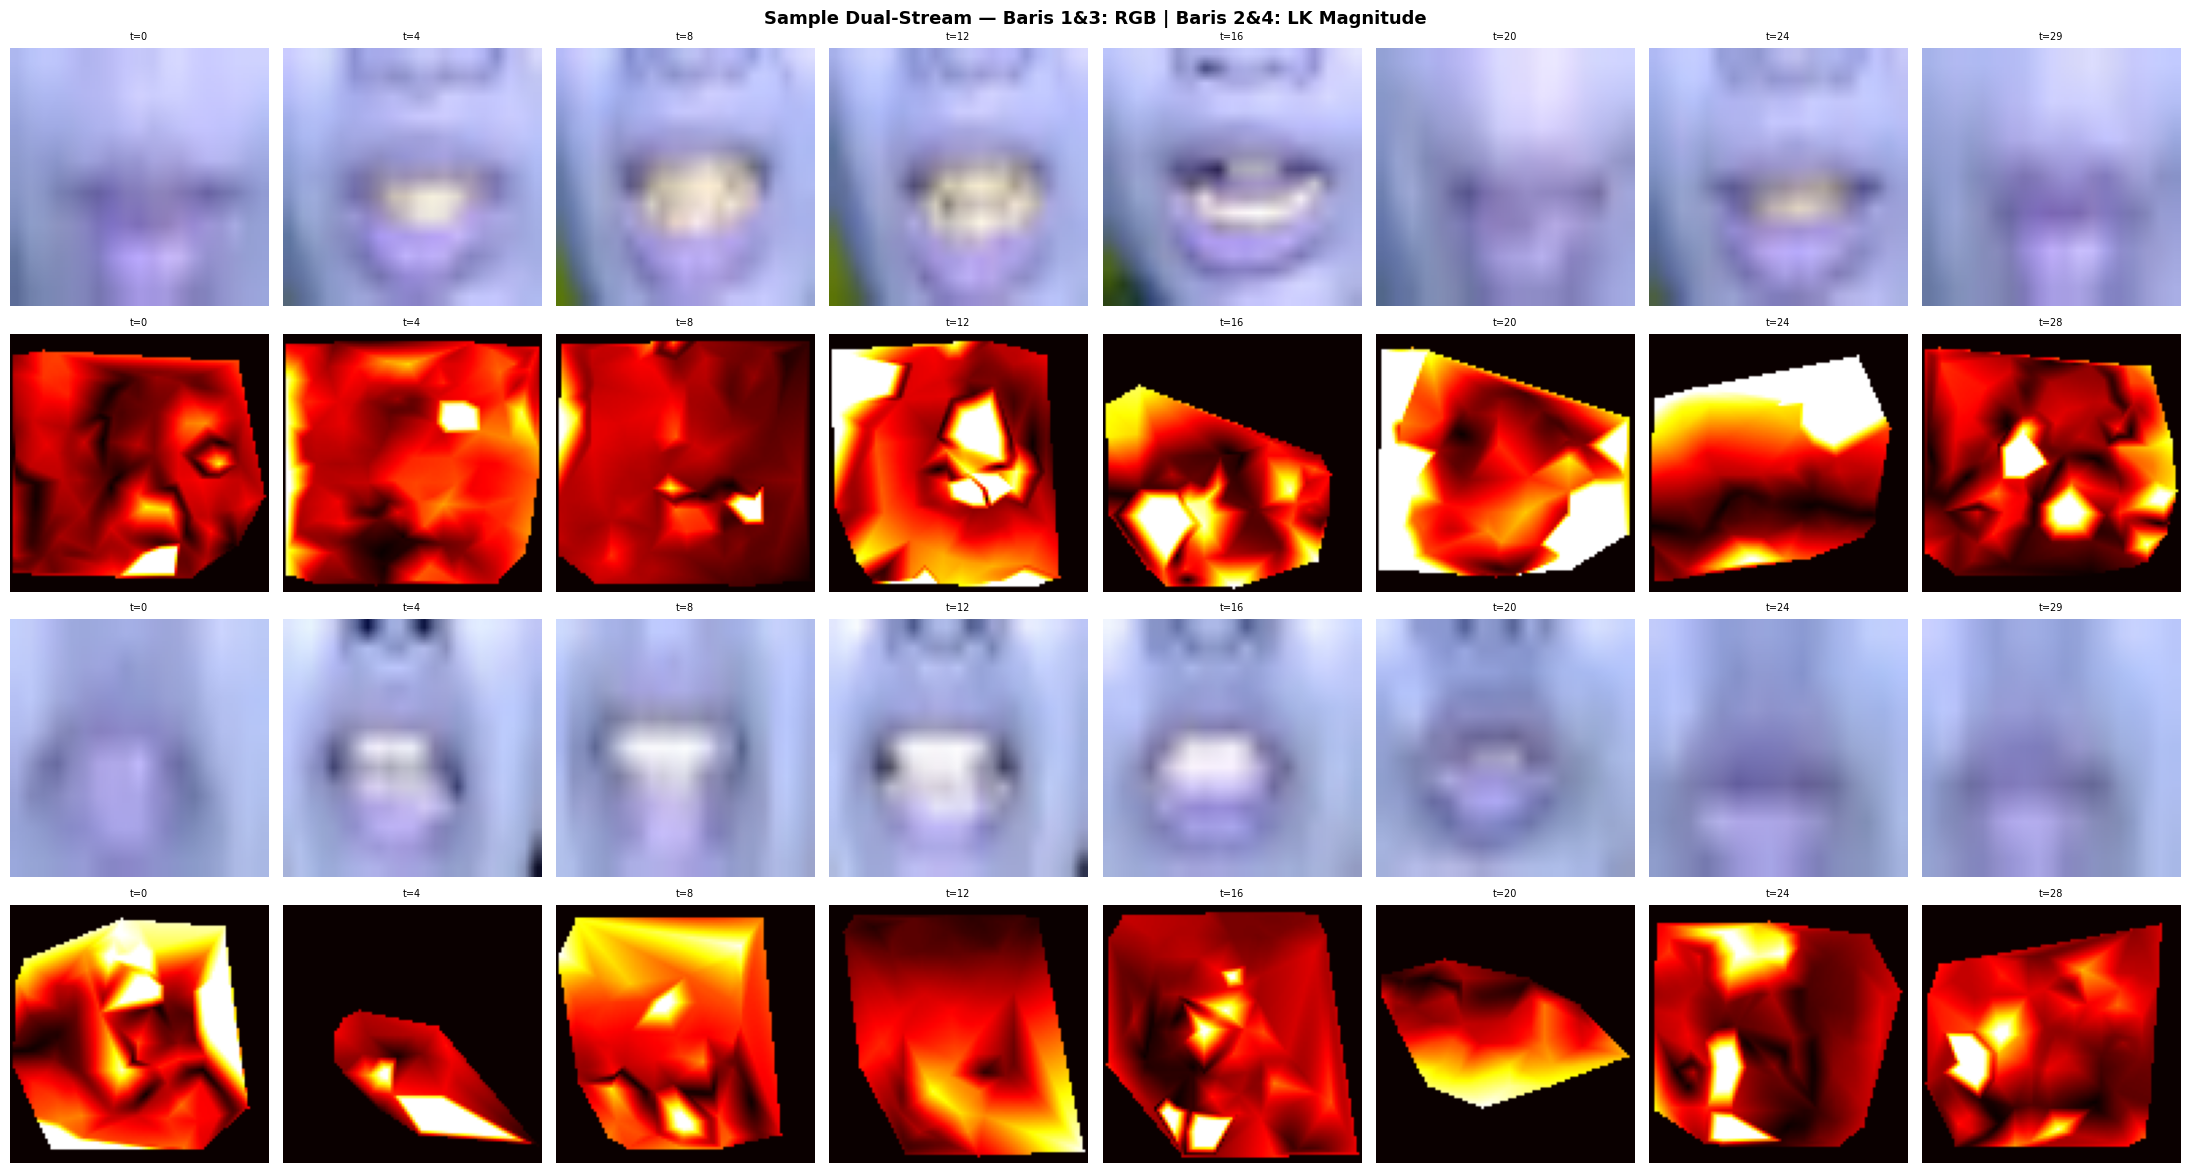

Saved: sample_dual_frames.png


In [5]:
# ── Cell 5: Visualisasi sampel ──────────────────────────────────────────────
fig, axes = plt.subplots(4, 8, figsize=(22, 12))
fig.suptitle('Sample Dual-Stream — Baris 1&3: RGB | Baris 2&4: LK Magnitude',
             fontsize=13, fontweight='bold')

for row in range(2):
    rgb_s, flow_s, lbl = train_ds[random.randint(0, len(train_ds)-1)]
    cls_name = IDX_TO_CLASS[lbl.item()]
    for col, t_rgb in enumerate(np.linspace(0, RGB_SEQ_LEN-1, 8, dtype=int)):
        # RGB frame
        frame = rgb_s[:, t_rgb].permute(1, 2, 0).numpy()
        axes[row*2][col].imshow(frame)
        axes[row*2][col].set_title(f't={t_rgb}', fontsize=7)
        axes[row*2][col].axis('off')
        # Flow magnitude (ch=2)
        t_fl = min(t_rgb, FLOW_SEQ_LEN - 1)
        axes[row*2+1][col].imshow(flow_s[2, t_fl].numpy(), cmap='hot')
        axes[row*2+1][col].set_title(f't={t_fl}', fontsize=7)
        axes[row*2+1][col].axis('off')
    axes[row*2][0].set_ylabel(f'RGB\n"{cls_name}"', fontsize=9, fontweight='bold')
    axes[row*2+1][0].set_ylabel(f'LK magnitude\n"{cls_name}"', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'sample_dual_frames.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: sample_dual_frames.png')

In [6]:
# ── Cell 6: ConvLSTM Cell ───────────────────────────────────────────────────
class ConvLSTMCell(nn.Module):
    """
    ConvLSTM menggantikan matrix multiplication LSTM dengan Conv2D.
    Informasi spasial tetap terjaga di dalam hidden state.
    Ref: Shi et al. (2015), NeurIPS.
    """
    def __init__(self, in_ch, h_ch, k=3):
        super().__init__()
        self.h_ch = h_ch
        self.conv = nn.Conv2d(in_ch + h_ch, 4 * h_ch, k, padding=k // 2)

    def forward(self, x, state):
        h, c = state
        i, f, o, g = torch.split(self.conv(torch.cat([x, h], dim=1)), self.h_ch, dim=1)
        c_next = torch.sigmoid(f) * c + torch.sigmoid(i) * torch.tanh(g)
        h_next = torch.sigmoid(o) * torch.tanh(c_next)
        return h_next, c_next

    def init_hidden(self, B, H, W, dev):
        return (torch.zeros(B, self.h_ch, H, W, device=dev),
                torch.zeros(B, self.h_ch, H, W, device=dev))


# ── Cell 7: Stream Encoder ───────────────────────────────────────────────────
class StreamEncoder(nn.Module):
    """
    Encoder per-stream: Conv2D spatial → ConvLSTM temporal → feature 64-dim.
    Arsitektur identik dengan BaselineModel dan LKFlowModel,
    bedanya output adalah feature vector (bukan logit langsung).
    """
    def __init__(self, in_ch=3):
        super().__init__()
        def cblock(ic, oc):
            return nn.Sequential(
                nn.Conv2d(ic, oc, 3, padding=1),
                nn.BatchNorm2d(oc),
                nn.ReLU(),
                nn.MaxPool2d(2)
            )
        # Spatial CNN: 96 → 48 → 24 → 12
        self.cnn   = nn.Sequential(cblock(in_ch, 32), cblock(32, 64), cblock(64, 128))
        self.lstm1 = ConvLSTMCell(128, 128)
        self.lstm2 = ConvLSTMCell(128, 64)

    def forward(self, x):                              # x: [B, C, T, H, W]
        B, C, T, H, W = x.shape
        x = x.permute(0, 2, 1, 3, 4).reshape(B*T, C, H, W)
        x = self.cnn(x)                                # [B*T, 128, 12, 12]
        _, c, h, w = x.shape
        x = x.view(B, T, c, h, w)

        h1, c1 = self.lstm1.init_hidden(B, h, w, x.device)
        h2, c2 = self.lstm2.init_hidden(B, h, w, x.device)
        for t in range(T):
            h1, c1 = self.lstm1(x[:, t], (h1, c1))
            h2, c2 = self.lstm2(h1, (h2, c2))

        return h2.mean(dim=[-2, -1])                   # [B, 64]


# ── Cell 8: Attention Fusion ─────────────────────────────────────────────────
class AttentionFusion(nn.Module):
    """
    Hitung bobot adaptif untuk tiap stream secara dinamis.
    Kalau LK flow kurang informatif (area flat, sedikit corner point),
    gate_flow mengecil otomatis → tidak merusak fitur RGB.

    Dibanding simple concat, fusion ini:
    - Memberi model kemampuan selektif menggunakan stream yang lebih informatif
    - Tidak menggandakan dimensi feature ke 128 (tetap 64)
    """
    def __init__(self, feat_dim=64):
        super().__init__()
        self.w_rgb  = nn.Linear(feat_dim * 2, feat_dim)
        self.w_flow = nn.Linear(feat_dim * 2, feat_dim)

    def forward(self, rgb_feat, flow_feat):
        combined  = torch.cat([rgb_feat, flow_feat], dim=1)  # [B, 128]
        gate_rgb  = torch.sigmoid(self.w_rgb(combined))      # [B, 64]
        gate_flow = torch.sigmoid(self.w_flow(combined))     # [B, 64]
        return gate_rgb * rgb_feat + gate_flow * flow_feat   # [B, 64]


# ── Cell 9: Model Utama ───────────────────────────────────────────────────────
class DualStreamModel(nn.Module):
    """
    Dual-Stream Conv-LSTM:
    - RGB stream  → StreamEncoder → rgb_feat  [B, 64]
    - Flow stream → StreamEncoder → flow_feat [B, 64]
    - AttentionFusion → fused [B, 64]
    - Classifier: FC(64→256) + ReLU + Dropout + FC(256→N)
    """
    def __init__(self, num_classes, dropout=0.5):
        super().__init__()
        self.rgb_enc    = StreamEncoder(in_ch=3)
        self.flow_enc   = StreamEncoder(in_ch=3)
        self.fusion     = AttentionFusion(feat_dim=64)
        self.head       = nn.Sequential(
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, rgb, flow):
        rgb_feat  = self.rgb_enc(rgb)
        flow_feat = self.flow_enc(flow)
        fused     = self.fusion(rgb_feat, flow_feat)
        return self.head(fused)

In [7]:
# ── Cell 10: Init model + ukur efisiensi ────────────────────────────────────
model = DualStreamModel(num_classes=NUM_CLASSES, dropout=0.5).to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
model_size_mb    = total_params * 4 / 1e6

# inference time (satu pasang RGB+flow)
dummy_rgb  = torch.randn(1, 3, RGB_SEQ_LEN,  96, 96).to(device)
dummy_flow = torch.randn(1, 3, FLOW_SEQ_LEN, 96, 96).to(device)

try:
    from thop import profile
    macs, _ = profile(model, inputs=(dummy_rgb, dummy_flow), verbose=False)
    gflops  = macs * 2 / 1e9
    gflops_str = f'{gflops:.3f} GFLOPs'
except ImportError:
    gflops = total_params * (RGB_SEQ_LEN + FLOW_SEQ_LEN) * 2 / 1e9
    gflops_str = f'~{gflops:.3f} GFLOPs (estimasi)'

model.eval()
with torch.no_grad():
    for _ in range(5): _ = model(dummy_rgb, dummy_flow)
    if torch.cuda.is_available(): torch.cuda.synchronize()
    t0 = time.time()
    for _ in range(50): _ = model(dummy_rgb, dummy_flow)
    if torch.cuda.is_available(): torch.cuda.synchronize()
    infer_ms = (time.time() - t0) / 50 * 1000
model.train()

# forward pass check
with torch.no_grad():
    test_out = model(torch.randn(2,3,RGB_SEQ_LEN,96,96).to(device),
                     torch.randn(2,3,FLOW_SEQ_LEN,96,96).to(device))

print('=' * 60)
print('  MODEL SUMMARY — Dual-Stream RGB + Lucas-Kanade')
print('=' * 60)
print(f'  Arsitektur       : 2× StreamEncoder + AttentionFusion')
print(f'  RGB input        : [B, 3, {RGB_SEQ_LEN}, 96, 96]')
print(f'  Flow input       : [B, 3, {FLOW_SEQ_LEN}, 96, 96]  (u, v, magnitude)')
print(f'  Total params     : {total_params:,}')
print(f'  Trainable params : {trainable_params:,}')
print(f'  Model size       : {model_size_mb:.2f} MB (float32)')
print(f'  GFLOPs           : {gflops_str}')
print(f'  Inference time   : {infer_ms:.2f} ms/sample (GPU)')
print(f'  Output shape     : {test_out.shape}  (expected [2, {NUM_CLASSES}])')
print('=' * 60)

  MODEL SUMMARY — Dual-Stream RGB + Lucas-Kanade
  Arsitektur       : 2× StreamEncoder + AttentionFusion
  RGB input        : [B, 3, 30, 96, 96]
  Flow input       : [B, 3, 29, 96, 96]  (u, v, magnitude)
  Total params     : 3,470,738
  Trainable params : 3,470,738
  Model size       : 13.88 MB (float32)
  GFLOPs           : ~0.410 GFLOPs (estimasi)
  Inference time   : 15.92 ms/sample (GPU)
  Output shape     : torch.Size([2, 18])  (expected [2, 18])


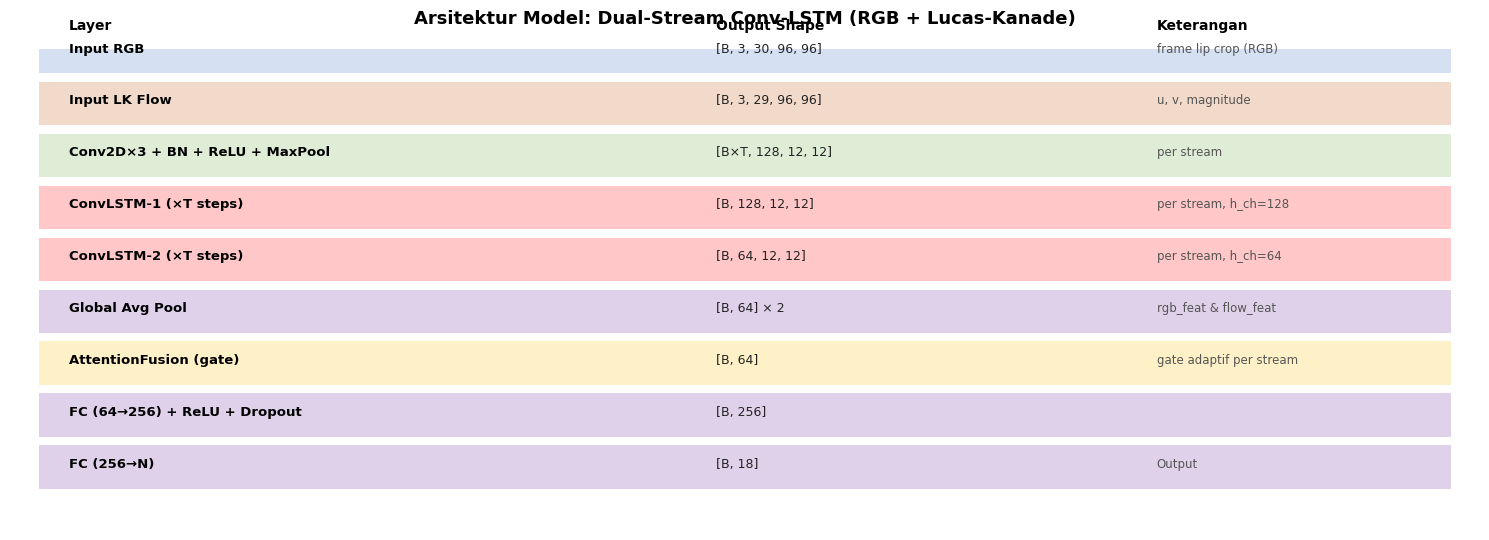

Saved: model_architecture.png


In [8]:
# ── Cell 11: Visualisasi arsitektur model ───────────────────────────────────
layers_info = [
    ('Input RGB',                      f'[B, 3, {RGB_SEQ_LEN}, 96, 96]',   'frame lip crop (RGB)'),
    ('Input LK Flow',                  f'[B, 3, {FLOW_SEQ_LEN}, 96, 96]',  'u, v, magnitude'),
    ('Conv2D×3 + BN + ReLU + MaxPool', '[B×T, 128, 12, 12]',               'per stream'),
    ('ConvLSTM-1 (×T steps)',          '[B, 128, 12, 12]',                  'per stream, h_ch=128'),
    ('ConvLSTM-2 (×T steps)',          '[B, 64, 12, 12]',                   'per stream, h_ch=64'),
    ('Global Avg Pool',                '[B, 64] × 2',                        'rgb_feat & flow_feat'),
    ('AttentionFusion (gate)',          '[B, 64]',                            'gate adaptif per stream'),
    ('FC (64→256) + ReLU + Dropout',   '[B, 256]',                           ''),
    ('FC (256→N)',                      f'[B, {NUM_CLASSES}]',                'Output'),
]

fig, ax = plt.subplots(figsize=(15, 5.5))
ax.axis('off')
colors = ['#4472C4', '#C55A11', '#70AD47', '#FF0000', '#FF0000',
          '#7030A0', '#FFC000', '#7030A0', '#7030A0']

for i, (name, shape, note) in enumerate(layers_info):
    y = 1 - i * 0.108
    ax.add_patch(plt.Rectangle((0.02, y-0.05), 0.96, 0.09,
                                facecolor=colors[i], alpha=0.22, transform=ax.transAxes))
    ax.text(0.04, y, name,  transform=ax.transAxes, va='center', fontsize=9.5, fontweight='bold')
    ax.text(0.48, y, shape, transform=ax.transAxes, va='center', fontsize=9,   color='#222')
    ax.text(0.78, y, note,  transform=ax.transAxes, va='center', fontsize=8.5, color='#555')

ax.text(0.04, 1.04, 'Layer',        transform=ax.transAxes, fontsize=10, fontweight='bold')
ax.text(0.48, 1.04, 'Output Shape', transform=ax.transAxes, fontsize=10, fontweight='bold')
ax.text(0.78, 1.04, 'Keterangan',  transform=ax.transAxes, fontsize=10, fontweight='bold')
ax.set_title('Arsitektur Model: Dual-Stream Conv-LSTM (RGB + Lucas-Kanade)',
             fontsize=13, fontweight='bold', pad=18)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'model_architecture.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: model_architecture.png')

In [9]:
# ── Cell 12: Loss, optimizer, scheduler ─────────────────────────────────────
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
# patience=8 karena dual-stream membutuhkan lebih banyak waktu untuk stabil
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=8, min_lr=1e-6)

print('Loss      : CrossEntropyLoss')
print('Optimizer : Adam')
print('Scheduler : ReduceLROnPlateau (mode=max, factor=0.5, patience=8)')
print('Grad clip : max_norm=1.0')


# ── Cell 13: Fungsi train & eval ────────────────────────────────────────────
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    loss_sum, correct, total = 0., 0, 0
    for rgb, flow, y in tqdm(loader, desc='Train', leave=False):
        rgb, flow, y = rgb.to(device), flow.to(device), y.to(device)
        optimizer.zero_grad()
        out  = model(rgb, flow)
        loss = criterion(out, y)
        loss.backward()
        # gradient clipping untuk stabilitas training dual-stream
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        loss_sum += loss.item() * y.size(0)
        correct  += (out.argmax(1) == y).sum().item()
        total    += y.size(0)
    return loss_sum / total, 100. * correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    loss_sum, correct, total = 0., 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for rgb, flow, y in tqdm(loader, desc='Eval', leave=False):
            rgb, flow, y = rgb.to(device), flow.to(device), y.to(device)
            out  = model(rgb, flow)
            loss = criterion(out, y)
            loss_sum += loss.item() * y.size(0)
            pred = out.argmax(1)
            correct  += (pred == y).sum().item()
            total    += y.size(0)
            all_preds.extend(pred.cpu().tolist())
            all_labels.extend(y.cpu().tolist())

    avg_loss = loss_sum / total
    accuracy = 100. * correct / total
    per_class = {}
    for ci in range(NUM_CLASSES):
        mask = [l == ci for l in all_labels]
        if any(mask):
            c = sum(p == ci for p, m in zip(all_preds, mask) if m)
            per_class[ci] = 100. * c / sum(mask)
        else:
            per_class[ci] = 0.
    return avg_loss, accuracy, per_class, all_preds, all_labels

print('setup selesai')

Loss      : CrossEntropyLoss
Optimizer : Adam
Scheduler : ReduceLROnPlateau (mode=max, factor=0.5, patience=8)
Grad clip : max_norm=1.0
setup selesai


In [10]:
# ── Cell 14: Training loop ──────────────────────────────────────────────────
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [],
           'lr': [], 'epoch_time': []}

best_val_acc    = 0.
best_epoch      = 0
best_model_path = MODELS_DIR / 'dualstream_lk_gabungan_best.pth'

t_start = time.time()
print(f'Training {NUM_EPOCHS} epochs | {len(train_loader)} batches/epoch | {NUM_CLASSES} kelas\n')
print(f'{"Epoch":>6}  {"TrainLoss":>10} {"TrainAcc":>9} {"ValLoss":>9} {"ValAcc":>8}  {"LR":>8}  {"Time":>6}  {"Flag"}')
print('-' * 90)

for epoch in range(1, NUM_EPOCHS + 1):
    t_ep = time.time()

    tr_loss, tr_acc                = train_one_epoch(model, train_loader, criterion, optimizer, device)
    va_loss, va_acc, per_cls, _, _ = evaluate(model, val_loader, criterion, device)

    scheduler.step(va_acc)
    cur_lr     = optimizer.param_groups[0]['lr']
    epoch_time = time.time() - t_ep

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(va_loss)
    history['val_acc'].append(va_acc)
    history['lr'].append(cur_lr)
    history['epoch_time'].append(epoch_time)

    flag = ''
    if va_acc > best_val_acc:
        best_val_acc = va_acc
        best_epoch   = epoch
        torch.save({
            'epoch'               : epoch,
            'model_state_dict'    : model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc'             : va_acc,
            'val_loss'            : va_loss,
            'num_classes'         : NUM_CLASSES,
            'classes'             : CLASSES,
            'method'              : 'dual-stream-lucaskanade'
        }, best_model_path)
        flag = '<-- best'

    print(f'{epoch:6d}  {tr_loss:10.4f} {tr_acc:9.2f}% {va_loss:9.4f} {va_acc:8.2f}%  {cur_lr:8.2e}  {epoch_time:5.0f}s  {flag}')
    cls_str = '  '.join([f'{IDX_TO_CLASS[k]}:{v:.0f}%' for k, v in per_cls.items()])
    print(f'         per-class: {cls_str}')

    if torch.cuda.is_available() and epoch % 5 == 0:
        torch.cuda.empty_cache()

total_time = time.time() - t_start
print('\n' + '=' * 90)
print(f'Training selesai dalam {total_time/60:.1f} menit')
print(f'Best val acc: {best_val_acc:.2f}% di epoch {best_epoch}')
print(f'Model disimpan: {best_model_path}')

Training 100 epochs | 315 batches/epoch | 18 kelas

 Epoch   TrainLoss  TrainAcc   ValLoss   ValAcc        LR    Time  Flag
------------------------------------------------------------------------------------------


Train:   0%|          | 0/315 [00:00<?, ?it/s]

Eval:   0%|          | 0/90 [00:00<?, ?it/s]

     1      2.8432      9.09%    2.8944     8.61%  1.00e-03    114s  <-- best
         per-class: 1:0%  2:0%  3:0%  8:0%  9:0%  10:88%  a:0%  b:0%  c:8%  d:0%  e:0%  f:0%  buku:42%  dia:18%  saya:0%  keliling:0%  kelompok:0%  sekarang:0%


Train:   0%|          | 0/315 [00:00<?, ?it/s]

...

Eval:   0%|          | 0/90 [00:00<?, ?it/s]

    99      0.0106     99.68%    0.8819    85.28%  2.50e-04    115s  
         per-class: 1:92%  2:95%  3:92%  8:85%  9:95%  10:92%  a:100%  b:95%  c:52%  d:68%  e:72%  f:90%  buku:95%  dia:85%  saya:88%  keliling:80%  kelompok:82%  sekarang:75%


Train:   0%|          | 0/315 [00:00<?, ?it/s]

Eval:   0%|          | 0/90 [00:00<?, ?it/s]

   100      0.0083     99.76%    0.9221    84.03%  2.50e-04    115s  
         per-class: 1:95%  2:92%  3:78%  8:85%  9:88%  10:95%  a:100%  b:95%  c:70%  d:65%  e:65%  f:88%  buku:95%  dia:80%  saya:78%  keliling:80%  kelompok:82%  sekarang:82%

Training selesai dalam 192.1 menit
Best val acc: 85.56% di epoch 97
Model disimpan: /home/wipra-ranum/Documents/Skripsi/LipReading/Lip_Reading_Gabungan/models/dualstream_lk_gabungan_best.pth


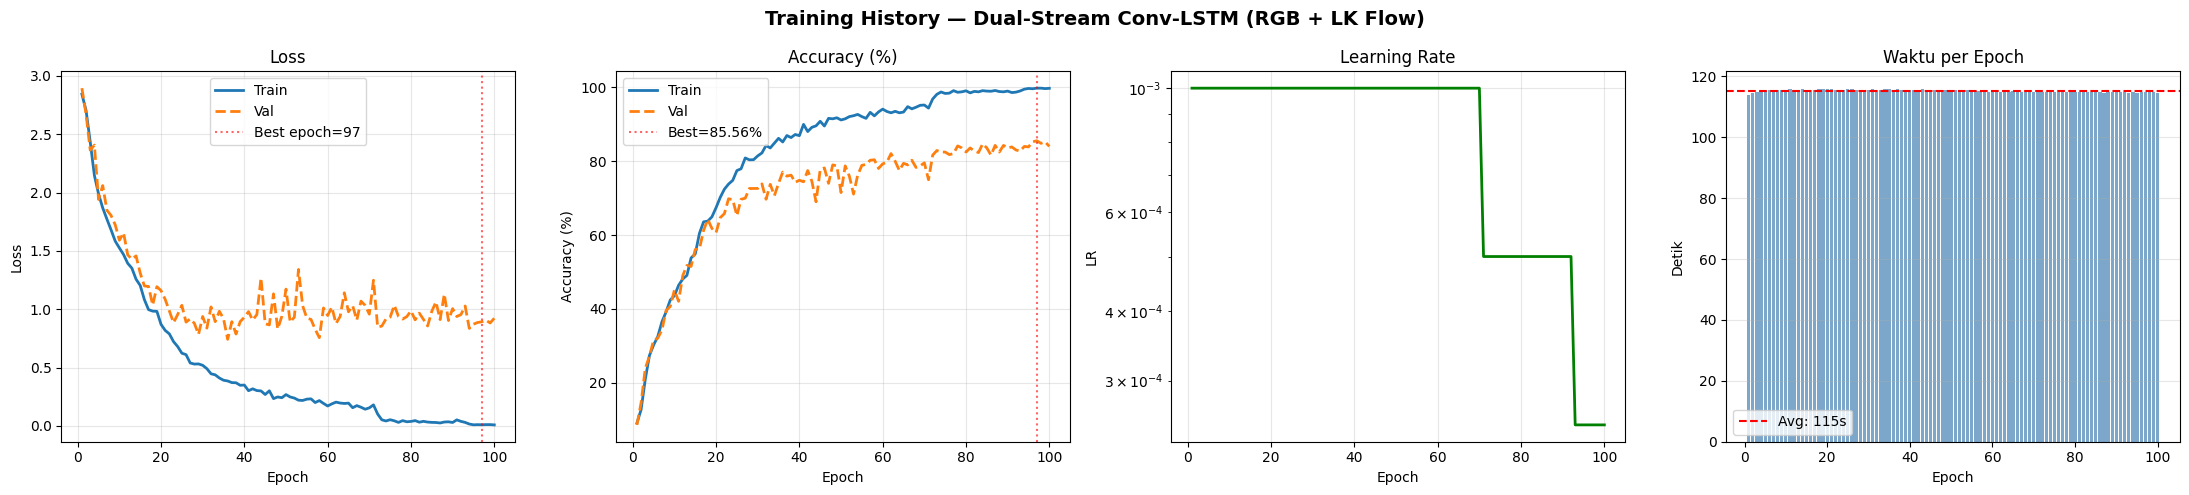

Saved: training_curves.png


In [11]:
# ── Cell 15: Training curves ────────────────────────────────────────────────
ep_ran   = len(history['train_loss'])
ep_range = range(1, ep_ran + 1)

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle('Training History — Dual-Stream Conv-LSTM (RGB + LK Flow)', fontsize=14, fontweight='bold')

axes[0].plot(ep_range, history['train_loss'], label='Train', linewidth=2)
axes[0].plot(ep_range, history['val_loss'],   label='Val',   linewidth=2, linestyle='--')
axes[0].axvline(best_epoch, color='red', linestyle=':', alpha=0.6, label=f'Best epoch={best_epoch}')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep_range, history['train_acc'], label='Train', linewidth=2)
axes[1].plot(ep_range, history['val_acc'],   label='Val',   linewidth=2, linestyle='--')
axes[1].axvline(best_epoch, color='red', linestyle=':', alpha=0.6, label=f'Best={best_val_acc:.2f}%')
axes[1].set_title('Accuracy (%)'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(ep_range, history['lr'], linewidth=2, color='green')
axes[2].set_title('Learning Rate'); axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('LR')
axes[2].set_yscale('log'); axes[2].grid(alpha=0.3)

axes[3].bar(ep_range, history['epoch_time'], color='steelblue', alpha=0.7)
axes[3].axhline(np.mean(history['epoch_time']), color='red', linestyle='--',
                label=f'Avg: {np.mean(history["epoch_time"]):.0f}s')
axes[3].set_title('Waktu per Epoch'); axes[3].set_xlabel('Epoch'); axes[3].set_ylabel('Detik')
axes[3].legend(); axes[3].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: training_curves.png')

In [12]:
# ── Cell 16: Load best model & evaluasi test set ────────────────────────────
ckpt = torch.load(best_model_path, map_location=device, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
print(f'Loaded best model epoch {ckpt["epoch"]} (val acc: {ckpt["val_acc"]:.2f}%)\n')

test_loss, test_acc, test_per_cls, test_preds, test_labels = evaluate(
    model, test_loader, criterion, device
)

f1_macro   = f1_score(test_labels, test_preds, average='macro')    * 100
f1_weight  = f1_score(test_labels, test_preds, average='weighted') * 100
prec_macro = precision_score(test_labels, test_preds, average='macro',    zero_division=0) * 100
rec_macro  = recall_score(test_labels,   test_preds, average='macro',     zero_division=0) * 100
prec_w     = precision_score(test_labels, test_preds, average='weighted', zero_division=0) * 100
rec_w      = recall_score(test_labels,   test_preds, average='weighted',  zero_division=0) * 100

print('\n' + '=' * 60)
print('  HASIL EVALUASI TEST SET — Dual-Stream RGB + LK')
print('=' * 60)
print(f'  Test Loss             : {test_loss:.4f}')
print(f'  Test Accuracy         : {test_acc:.2f}%')
print(f'  Precision (macro)     : {prec_macro:.2f}%')
print(f'  Precision (weighted)  : {prec_w:.2f}%')
print(f'  Recall    (macro)     : {rec_macro:.2f}%')
print(f'  Recall    (weighted)  : {rec_w:.2f}%')
print(f'  F1-score  (macro)     : {f1_macro:.2f}%')
print(f'  F1-score  (weighted)  : {f1_weight:.2f}%')
print('=' * 60)

Loaded best model epoch 97 (val acc: 85.56%)



Eval:   0%|          | 0/45 [00:00<?, ?it/s]


  HASIL EVALUASI TEST SET — Dual-Stream RGB + LK
  Test Loss             : 1.0857
  Test Accuracy         : 84.17%
  Precision (macro)     : 84.92%
  Precision (weighted)  : 84.92%
  Recall    (macro)     : 84.17%
  Recall    (weighted)  : 84.17%
  F1-score  (macro)     : 83.92%
  F1-score  (weighted)  : 83.92%


In [13]:
# ── Cell 17: Classification report ─────────────────────────────────────────
print('Classification Report per Kelas:\n')
print(classification_report(test_labels, test_preds, target_names=CLASSES, digits=3))

Classification Report per Kelas:

              precision    recall  f1-score   support

           1      0.870     1.000     0.930        20
           2      0.947     0.900     0.923        20
           3      1.000     0.650     0.788        20
           8      0.864     0.950     0.905        20
           9      0.882     0.750     0.811        20
          10      0.864     0.950     0.905        20
           a      0.905     0.950     0.927        20
           b      0.870     1.000     0.930        20
           c      0.650     0.650     0.650        20
           d      0.667     0.600     0.632        20
           e      0.704     0.950     0.809        20
           f      0.952     1.000     0.976        20
        buku      0.857     0.900     0.878        20
         dia      0.944     0.850     0.895        20
        saya      0.720     0.900     0.800        20
    keliling      0.778     0.700     0.737        20
    kelompok      0.938     0.750     0.833    

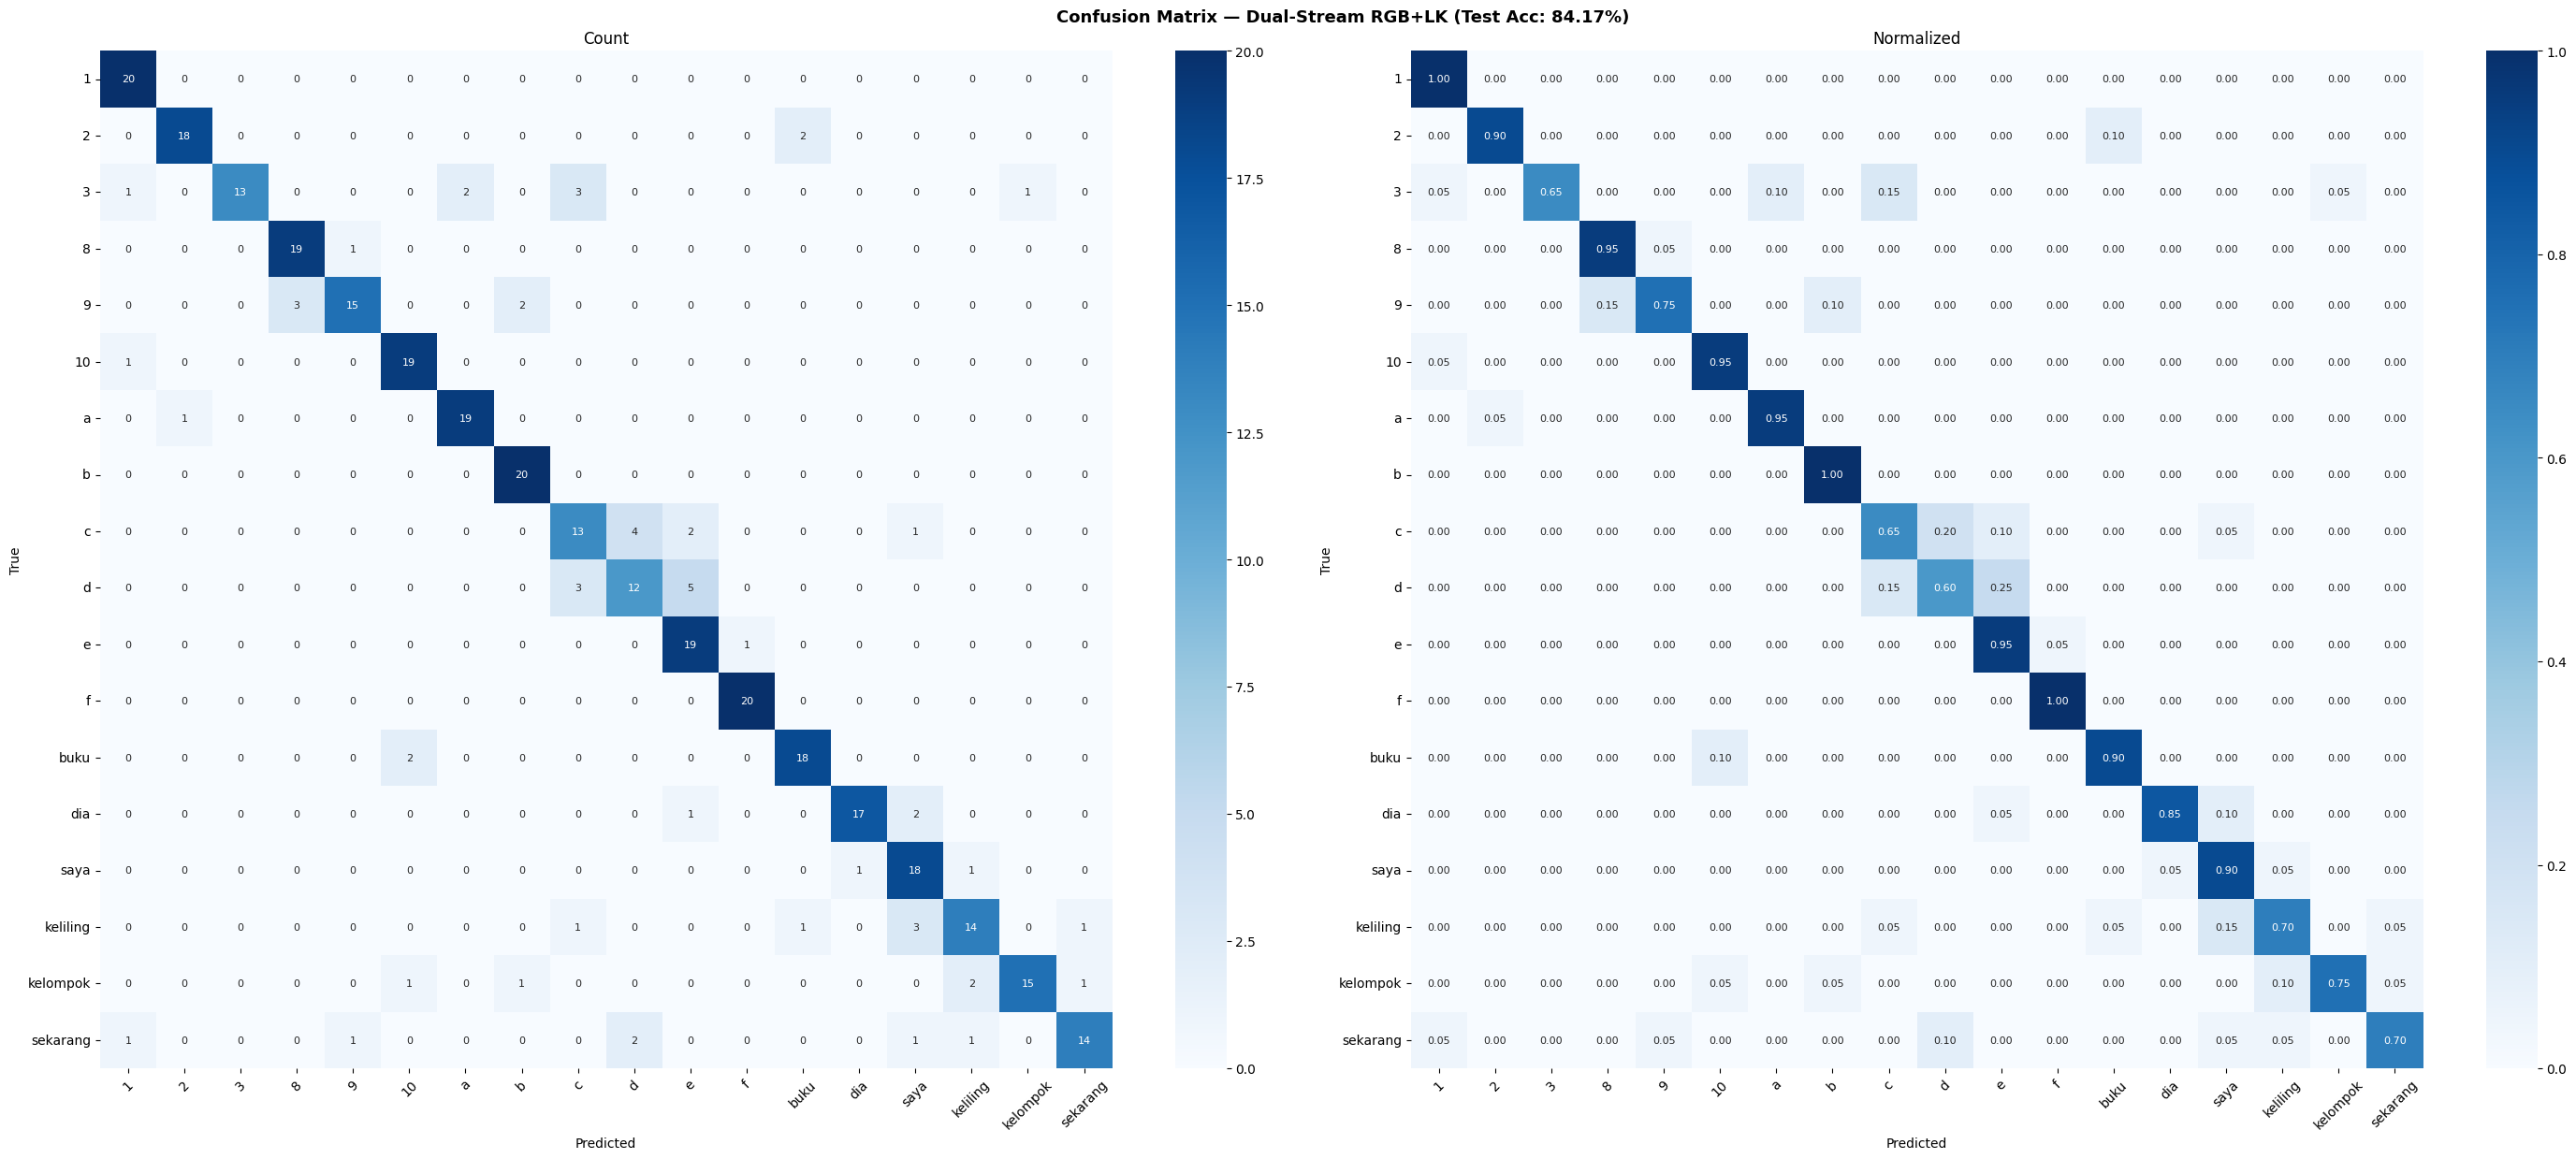

Saved: confusion_matrix.png


In [14]:
# ── Cell 18: Confusion matrix ───────────────────────────────────────────────
cm      = confusion_matrix(test_labels, test_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig_w = max(14, NUM_CLASSES * 0.8)
fig_h = max(10, NUM_CLASSES * 0.7)
fig, axes = plt.subplots(1, 2, figsize=(fig_w * 2, fig_h))
fig.suptitle(f'Confusion Matrix — Dual-Stream RGB+LK (Test Acc: {test_acc:.2f}%)',
             fontsize=13, fontweight='bold')

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=CLASSES, yticklabels=CLASSES, annot_kws={'size': 8})
axes[0].set_title('Count'); axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=axes[1],
            xticklabels=CLASSES, yticklabels=CLASSES, annot_kws={'size': 8}, vmin=0, vmax=1)
axes[1].set_title('Normalized'); axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrix.png')

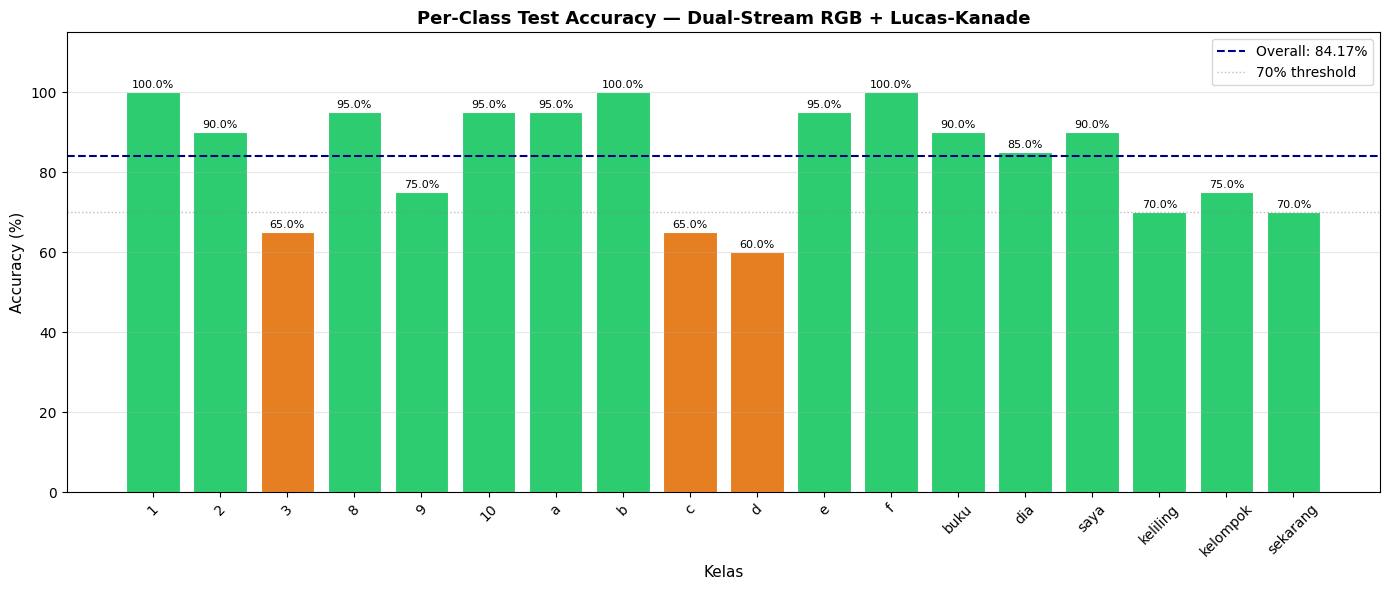

Saved: per_class_accuracy.png


In [15]:
# ── Cell 19: Per-class accuracy bar chart ───────────────────────────────────
class_accs = [test_per_cls[i] for i in range(NUM_CLASSES)]
colors_bar = ['#2ecc71' if a >= 70 else '#e67e22' if a >= 40 else '#e74c3c' for a in class_accs]

fig, ax = plt.subplots(figsize=(max(14, NUM_CLASSES * 0.7), 6))
bars = ax.bar(CLASSES, class_accs, color=colors_bar, edgecolor='white', linewidth=0.8)
for bar, acc in zip(bars, class_accs):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            f'{acc:.1f}%', ha='center', va='bottom', fontsize=8)
ax.axhline(test_acc, color='navy', linestyle='--', linewidth=1.5, label=f'Overall: {test_acc:.2f}%')
ax.axhline(70, color='gray', linestyle=':', linewidth=1, alpha=0.5, label='70% threshold')
ax.set_xlabel('Kelas', fontsize=11); ax.set_ylabel('Accuracy (%)', fontsize=11)
ax.set_title('Per-Class Test Accuracy — Dual-Stream RGB + Lucas-Kanade', fontsize=13, fontweight='bold')
ax.set_ylim([0, 115]); ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: per_class_accuracy.png')

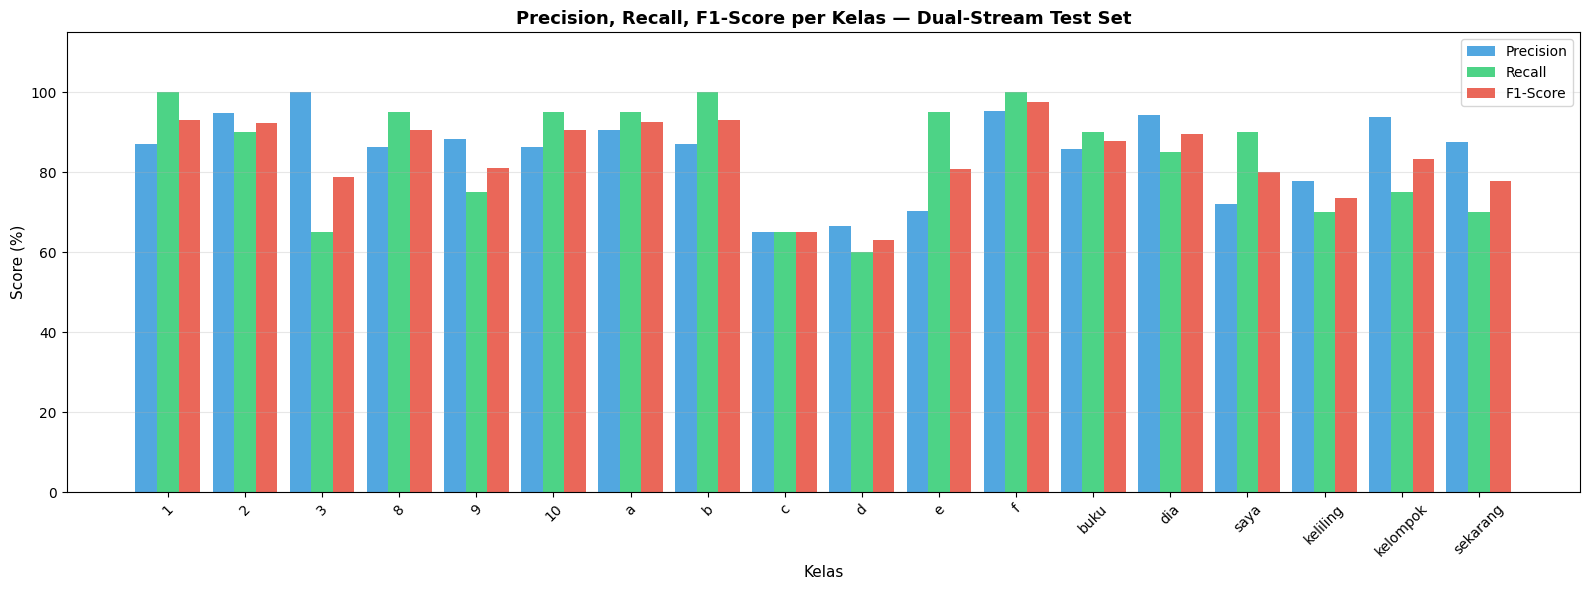

Saved: precision_recall_f1.png


In [16]:
# ── Cell 20: Precision, Recall, F1 per kelas ─────────────────────────────────
report_dict = classification_report(
    test_labels, test_preds, target_names=CLASSES, output_dict=True, zero_division=0
)

prec_per = [report_dict[c]['precision'] * 100 for c in CLASSES]
rec_per  = [report_dict[c]['recall']    * 100 for c in CLASSES]
f1_per   = [report_dict[c]['f1-score']  * 100 for c in CLASSES]

x_pos = np.arange(NUM_CLASSES)
width = 0.28

fig, ax = plt.subplots(figsize=(max(16, NUM_CLASSES * 0.8), 6))
ax.bar(x_pos - width, prec_per, width, label='Precision', color='#3498db', alpha=0.85)
ax.bar(x_pos,         rec_per,  width, label='Recall',    color='#2ecc71', alpha=0.85)
ax.bar(x_pos + width, f1_per,   width, label='F1-Score',  color='#e74c3c', alpha=0.85)
ax.set_xticks(x_pos); ax.set_xticklabels(CLASSES, rotation=45)
ax.set_xlabel('Kelas', fontsize=11); ax.set_ylabel('Score (%)', fontsize=11)
ax.set_title('Precision, Recall, F1-Score per Kelas — Dual-Stream Test Set',
             fontsize=13, fontweight='bold')
ax.set_ylim([0, 115]); ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'precision_recall_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: precision_recall_f1.png')

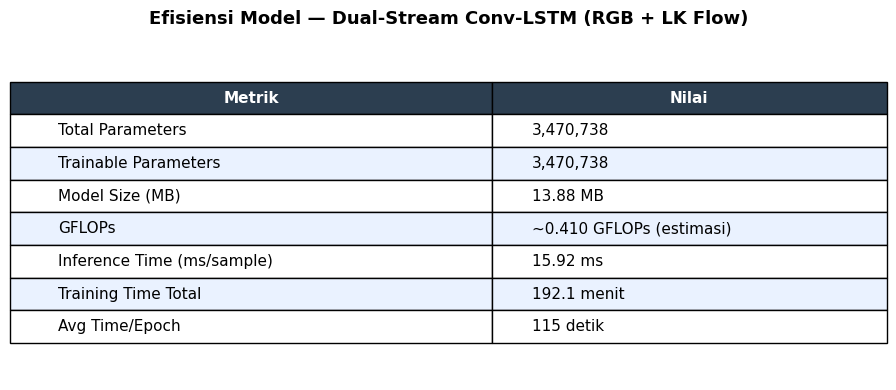

Saved: model_efficiency.png


In [17]:
# ── Cell 21: Ringkasan efisiensi model ──────────────────────────────────────
efficiency_data = {
    'Metrik' : ['Total Parameters', 'Trainable Parameters', 'Model Size (MB)',
                 'GFLOPs', 'Inference Time (ms/sample)',
                 'Training Time Total', 'Avg Time/Epoch'],
    'Nilai'  : [
        f'{total_params:,}',
        f'{trainable_params:,}',
        f'{model_size_mb:.2f} MB',
        gflops_str,
        f'{infer_ms:.2f} ms',
        f'{total_time/60:.1f} menit',
        f'{np.mean(history["epoch_time"]):.0f} detik'
    ]
}

fig, ax = plt.subplots(figsize=(9, 4))
ax.axis('off')
df_eff = pd.DataFrame(efficiency_data)
tbl = ax.table(cellText=df_eff.values, colLabels=df_eff.columns,
               cellLoc='left', loc='center', colWidths=[0.55, 0.45])
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.2, 1.8)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2C3E50')
        cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#EAF2FF')
ax.set_title('Efisiensi Model — Dual-Stream Conv-LSTM (RGB + LK Flow)',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'model_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: model_efficiency.png')

In [18]:
# ── Cell 22: Tabel perbandingan semua metode ────────────────────────────────
# Isi manual dari hasil notebook sebelumnya
comparison = {
    'Baseline RGB Conv-LSTM'             : {'val': 84.58, 'test': 83.06},
    'LK Flow Conv-LSTM'                  : {'val': 51.67, 'test': 50.83},
    'Dual-Stream RGB + LK (notebook ini)': {'val': best_val_acc, 'test': test_acc},
}

print('=' * 68)
print('PERBANDINGAN METODE — Dataset Gabungan (18 kelas)')
print('=' * 68)
print(f'{"Metode":<48} {"Val Acc":>9} {"Test Acc":>9}')
print('-' * 68)
for nama, res in comparison.items():
    v = f'{res["val"]:.2f}%'
    t = f'{res["test"]:.2f}%'
    print(f'{nama:<48} {v:>9}  {t:>9}')
print('=' * 68)

# Hitung delta dual vs baseline
delta_val  = best_val_acc - comparison['Baseline RGB Conv-LSTM']['val']
delta_test = test_acc     - comparison['Baseline RGB Conv-LSTM']['test']
print(f'\nDelta Dual vs Baseline — Val : {delta_val:+.2f}% | Test: {delta_test:+.2f}%')

PERBANDINGAN METODE — Dataset Gabungan (18 kelas)
Metode                                             Val Acc  Test Acc
--------------------------------------------------------------------
Baseline RGB Conv-LSTM                              84.58%     83.06%
LK Flow Conv-LSTM                                   51.67%     50.83%
Dual-Stream RGB + LK (notebook ini)                 85.56%     84.17%

Delta Dual vs Baseline — Val : +0.98% | Test: +1.11%


In [19]:
# ── Cell 23: Save summary JSON + CSV ───────────────────────────────────────
summary = {
    'model'     : 'Dual-Stream Conv2D + ConvLSTM (RGB + Lucas-Kanade)',
    'dataset'   : 'SIBI Dependent Gabungan',
    'model_info': {
        'total_params'    : total_params,
        'trainable_params': trainable_params,
        'model_size_mb'   : round(model_size_mb, 2),
        'gflops'          : gflops_str,
        'inference_ms'    : round(infer_ms, 2),
        'rgb_input'       : f'[B, 3, {RGB_SEQ_LEN}, 96, 96]',
        'flow_input'      : f'[B, 3, {FLOW_SEQ_LEN}, 96, 96]'
    },
    'training'  : {
        'epochs_trained'    : ep_ran,
        'best_epoch'        : best_epoch,
        'batch_size'        : BATCH_SIZE,
        'learning_rate'     : LR,
        'weight_decay'      : WEIGHT_DECAY,
        'optimizer'         : 'Adam',
        'scheduler'         : 'ReduceLROnPlateau (max, factor=0.5, patience=8)',
        'augmentation'      : 'horizontal flip + negate u channel',
        'grad_clip'         : 'max_norm=1.0',
        'best_val_acc'      : round(best_val_acc, 4),
        'total_time_minutes': round(total_time / 60, 2),
        'avg_epoch_time_sec': round(np.mean(history['epoch_time']), 1)
    },
    'test_results': {
        'test_loss'         : round(test_loss, 4),
        'accuracy'          : round(test_acc, 4),
        'precision_macro'   : round(prec_macro, 4),
        'precision_weighted': round(prec_w, 4),
        'recall_macro'      : round(rec_macro, 4),
        'recall_weighted'   : round(rec_w, 4),
        'f1_macro'          : round(f1_macro, 4),
        'f1_weighted'       : round(f1_weight, 4),
        'per_class_acc'     : {CLASSES[i]: round(acc, 2) for i, acc in enumerate(class_accs)}
    }
}

with open(RESULTS_DIR / 'dualstream_lk_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

pd.DataFrame({
    'epoch'      : range(1, ep_ran + 1),
    'train_loss' : history['train_loss'],
    'train_acc'  : history['train_acc'],
    'val_loss'   : history['val_loss'],
    'val_acc'    : history['val_acc'],
    'lr'         : history['lr'],
    'epoch_time' : history['epoch_time']
}).to_csv(RESULTS_DIR / 'training_history.csv', index=False)

report_rows = []
for cls in CLASSES:
    r = report_dict[cls]
    report_rows.append({'class': cls, 'precision': round(r['precision']*100,2),
                        'recall': round(r['recall']*100,2), 'f1': round(r['f1-score']*100,2),
                        'support': int(r['support'])})
pd.DataFrame(report_rows).to_csv(RESULTS_DIR / 'classification_report.csv', index=False)

print('Files saved:')
all_files = [
    ('models',  'dualstream_lk_gabungan_best.pth'),
    ('results', 'dualstream_lk_summary.json'),
    ('results', 'training_history.csv'),
    ('results', 'classification_report.csv'),
    ('results', 'model_architecture.png'),
    ('results', 'sample_dual_frames.png'),
    ('results', 'training_curves.png'),
    ('results', 'confusion_matrix.png'),
    ('results', 'per_class_accuracy.png'),
    ('results', 'precision_recall_f1.png'),
    ('results', 'model_efficiency.png'),
]
for kind, fname in all_files:
    path = (MODELS_DIR if kind == 'models' else RESULTS_DIR) / fname
    print(f'  [{"✓" if path.exists() else "○"}] {fname}')

print(f'\nDual-Stream Training selesai!')
print(f'Test Accuracy  : {test_acc:.2f}%')
print(f'F1 (weighted)  : {f1_weight:.2f}%')
print(f'Best epoch     : {best_epoch}/{ep_ran}')
print(f'Delta vs Baseline — Test: {test_acc - 83.06:+.2f}%')

Files saved:
  [✓] dualstream_lk_gabungan_best.pth
  [✓] dualstream_lk_summary.json
  [✓] training_history.csv
  [✓] classification_report.csv
  [✓] model_architecture.png
  [✓] sample_dual_frames.png
  [✓] training_curves.png
  [✓] confusion_matrix.png
  [✓] per_class_accuracy.png
  [✓] precision_recall_f1.png
  [✓] model_efficiency.png

Dual-Stream Training selesai!
Test Accuracy  : 84.17%
F1 (weighted)  : 83.92%
Best epoch     : 97/100
Delta vs Baseline — Test: +1.11%
